In [8]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


Titanic Survival Prediction - ML Model
Building and comparing 3 machine learning models to predict Titanic passenger survival using Python and Scikit-learn.



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('train.csv')

# See first 5 rows
print("First 5 rows:")
print(df.head())

# Check shape
print("\nShape (rows, columns):", df.shape)

# Check column names and info
print("\nColumn Info:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

Step 2 - Data Cleaning & Preprocessing
Handling missing values, encoding categorical variables, and preparing data for machine learning.



In [10]:
# Fill Age missing values with median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked missing values with most common value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column (too many missing values - 687 out of 891)
df.drop(columns=['Cabin'], inplace=True)

# Drop columns not useful for prediction
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# Convert Sex column to numbers (male=0, female=1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Convert Embarked column to numbers (S=0, C=1, Q=2)
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Confirm no missing values
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nCleaned data shape:", df.shape)
print("\nFirst 5 rows after cleaning:")
print(df.head())
print("\nCleaning done! ✅")


Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Cleaned data shape: (891, 8)

First 5 rows after cleaning:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  22.0      1      0   7.2500         0
1         1       1    1  38.0      1      0  71.2833         1
2         1       3    1  26.0      0      0   7.9250         0
3         1       1    1  35.0      1      0  53.1000         0
4         0       3    0  35.0      0      0   8.0500         0

Cleaning done! ✅


Step 3 - Feature Engineering
Identifying the most important features using correlation analysis and dropping irrelevant ones.



Correlation with Survival:
Survived    1.000000
Sex         0.543351
Fare        0.257307
Embarked    0.106811
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Pclass     -0.338481
Name: Survived, dtype: float64


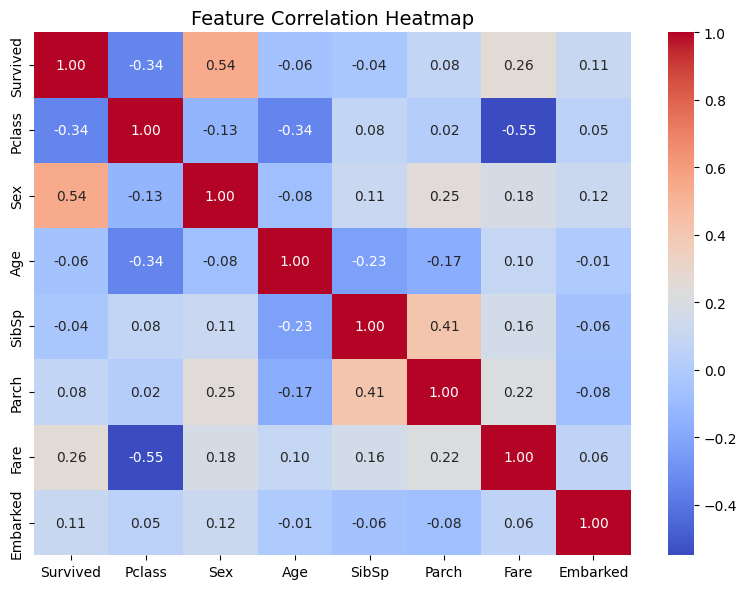


Features used for prediction: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Target variable: Survived (0=Died, 1=Survived)

Training set size: (712, 7)
Testing set size: (179, 7)

Data split done! ✅


In [11]:
# Check correlation of all features with Survived
print("Correlation with Survival:")
print(df.corr()['Survived'].sort_values(ascending=False))

# Plot correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Define features (X) and target (y)
X = df.drop(columns=['Survived'])  # All columns except Survived
y = df['Survived']                  # Only Survived column

print("\nFeatures used for prediction:", X.columns.tolist())
print("Target variable: Survived (0=Died, 1=Survived)")

# Split data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nData split done! ✅")

Step 4 - Training 3 Machine Learning Models
Training Logistic Regression, Random Forest, and KNN models on the Titanic dataset.

In [12]:
# ── MODEL 1: Logistic Regression ──
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("✅ Model 1: Logistic Regression trained!")

# ── MODEL 2: Random Forest ──
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("✅ Model 2: Random Forest trained!")

# ── MODEL 3: KNN ──
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
print("✅ Model 3: KNN trained!")

print("\nAll 3 models trained successfully! 🎉")

✅ Model 1: Logistic Regression trained!
✅ Model 2: Random Forest trained!
✅ Model 3: KNN trained!

All 3 models trained successfully! 🎉


Step 5 - Model Evaluation & Comparison
Evaluating all 3 models using Accuracy, Precision, Recall and F1 Score metrics.

In [13]:
# Calculate metrics for all 3 models
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy':  [accuracy_score(y_test, lr_pred),
                  accuracy_score(y_test, rf_pred),
                  accuracy_score(y_test, knn_pred)],
    'Precision': [precision_score(y_test, lr_pred),
                  precision_score(y_test, rf_pred),
                  precision_score(y_test, knn_pred)],
    'Recall':    [recall_score(y_test, lr_pred),
                  recall_score(y_test, rf_pred),
                  recall_score(y_test, knn_pred)],
    'F1 Score':  [f1_score(y_test, lr_pred),
                  f1_score(y_test, rf_pred),
                  f1_score(y_test, knn_pred)]
}

# Create comparison table
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
print("=" * 65)
print("         MODEL COMPARISON TABLE")
print("=" * 65)
print(results_df.to_string(index=False))
print("=" * 65)

# Show best model
best_model = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
best_accuracy = results_df['Accuracy'].max()
print(f"\n🏆 Best Model: {best_model} with Accuracy: {best_accuracy:.4f}")

         MODEL COMPARISON TABLE
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.7989     0.7714  0.7297    0.7500
      Random Forest    0.8268     0.8116  0.7568    0.7832
                KNN    0.6983     0.6786  0.5135    0.5846

🏆 Best Model: Random Forest with Accuracy: 0.8268


Step 6 - Best Model Analysis & Conclusion
Plotting confusion matrix for Random Forest (best model) and writing final conclusion.

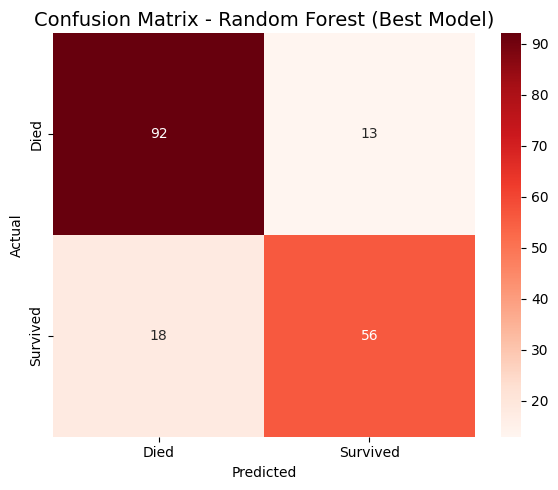

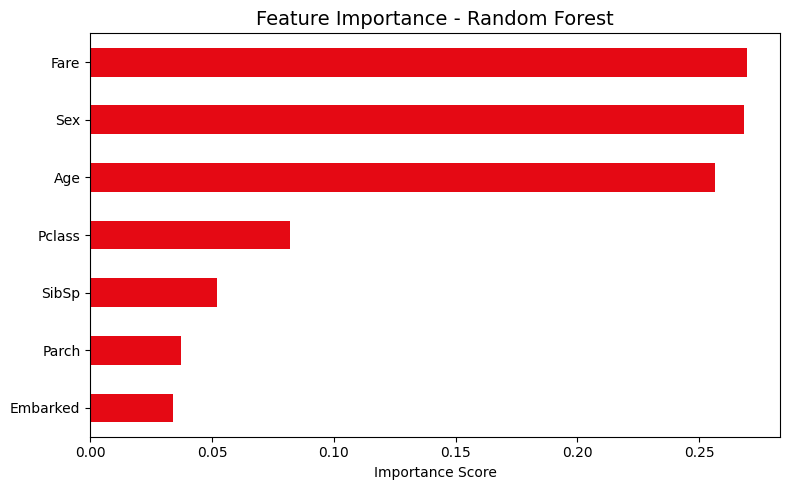

Charts created! ✅


In [14]:
# Confusion Matrix for best model (Random Forest)
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix - Random Forest (Best Model)', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance chart
plt.figure(figsize=(8,5))
feature_importance = pd.Series(rf_model.feature_importances_,
                                index=X.columns)
feature_importance.sort_values().plot(kind='barh', color='#E50914')
plt.title('Feature Importance - Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Charts created! ✅")

Step 7 - Final Conclusion
Model Comparison Summary:
Three machine learning models were trained and evaluated on the Titanic dataset — Logistic Regression (79.89%), Random Forest (82.68%), and KNN (69.83%).
Best Model: Random Forest with 82.68% Accuracy
Why Random Forest performed best:
Random Forest uses multiple decision trees and combines their results, making it more accurate and resistant to errors than a single model. It correctly identified 92 out of 105 deaths and 56 out of 74 survivals in the test set.
Key finding: Fare, Sex, and Age were the most important features in predicting survival. Females, younger passengers, and those who paid higher fares had significantly better survival chances — confirming the historical "women and children first" evacuation policy of the Titanic.
Most Surprising Finding:
Fare was the single most important predictor of survival, even more than Sex — suggesting that wealth and ticket class played a critical role in determining who survived the Titanic disaster.